# Business & Data Understanding (EDA) - Store Sales
Di tahap ini kita akan membongkar misteri di balik akurasi model dan gap RMSE yang sangat besar dibandingkan MAE. Fokus utama adalah:
1. Distribusi target demand (penjualan).
2. Pola *zero-sales* (hari di mana sales 0, apakah memang rilis/stok habis).
3. Anomali khusus: Gempa bumi (April 2016), Hari Libur Nasional tutup, dll.
4. Efek hari pembayaran gaji (*Paydays*).

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import psycopg2
from sqlalchemy import create_engine
import os

# Buat folder output untuk menyimpan gambar grafik (jika dijalankan via terminal)
os.makedirs('outputs', exist_ok=True)

# Konfigurasi plot agar lebih estetik
plt.style.use('ggplot')
sns.set_palette('muted')

# Load dataset CSV mentah (SuperMarket Analysis)
print("Loading Data CSV...")
dataset_path = 'store-sales-time-series-forecasting/train.csv'
if not os.path.exists(dataset_path):
    dataset_path = '../store-sales-time-series-forecasting/train.csv'
df_raw = pd.read_csv(dataset_path)
df_raw['date'] = pd.to_datetime(df_raw['date'])

print(f"Total baris dataset mentah: {len(df_raw):,}")
print("Contoh Data:")
display(df_raw.head()) if 'display' in globals() else print(df_raw.head())

Loading Data CSV...
Total baris dataset mentah: 3,000,888
Contoh Data:
   id       date  store_nbr      family  sales  onpromotion
0   0 2013-01-01          1  AUTOMOTIVE    0.0            0
1   1 2013-01-01          1   BABY CARE    0.0            0
2   2 2013-01-01          1      BEAUTY    0.0            0
3   3 2013-01-01          1   BEVERAGES    0.0            0
4   4 2013-01-01          1       BOOKS    0.0            0


### 1. Identifikasi Distribusi Penjualan (Target Tumbuh/Miring)

Grafik 1 (Distribusi Target) telah disave ke notebooks/outputs/1_distribusi_target.png


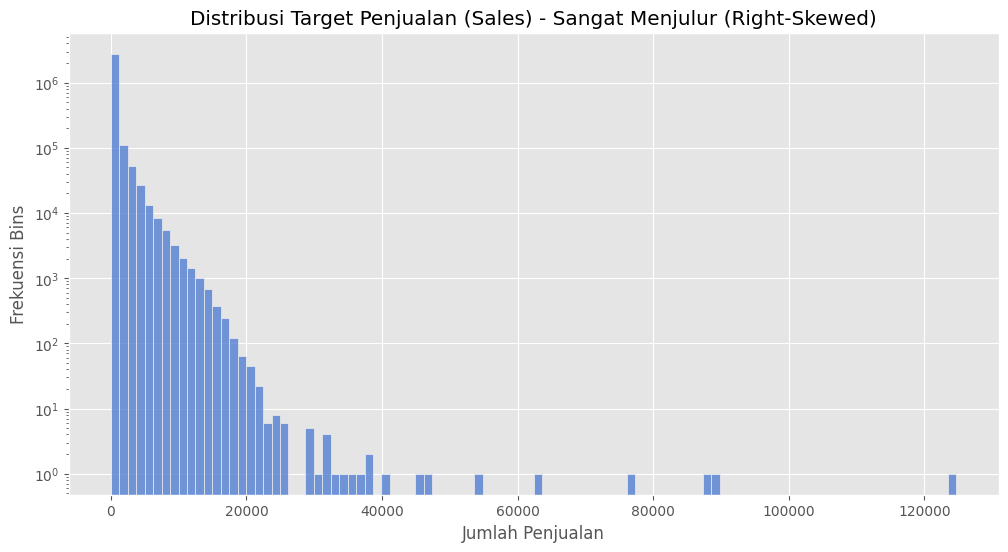

Total baris dengan PENJUALAN NOL (0): 939,130 (31.30% dari seluruh data)


In [6]:
plt.figure(figsize=(12, 6))
sns.histplot(df_raw['sales'], bins=100, kde=False)
plt.title('Distribusi Target Penjualan (Sales) - Sangat Menjulur (Right-Skewed)')
plt.xlabel('Jumlah Penjualan')
plt.ylabel('Frekuensi Bins')
plt.yscale('log') # Log scale untuk melihat keberadaan outlier dengan jelas
plt.savefig('outputs/1_distribusi_target.png')
print("Grafik 1 (Distribusi Target) telah disave ke notebooks/outputs/1_distribusi_target.png")
plt.show(block=False)
plt.pause(2)

# Pengecekan Zero Sales
zero_sales_count = len(df_raw[df_raw['sales'] == 0])
zero_sales_pct = (zero_sales_count / len(df_raw)) * 100
print(f"Total baris dengan PENJUALAN NOL (0): {zero_sales_count:,} ({zero_sales_pct:.2f}% dari seluruh data)")

Hampir **30% (atau lebih)** data penjualan adalah 0. Ini bisa berarti:
1. Toko benar-benar tutup.
2. Produk (family) belum dirilis di toko tersebut.
3. Kehabisan stok permanen.

Jika model ML ditempa dengan data yang menyatakan "barang ini tidak laku" padahal aslinya "barangnya memang belum diproduksi/dijual di toko itu", pohon keputusan (XGBoost/LightGBM) akan sangat kebingungan (RMSE meledak).

### 2. Eksplorasi Musiman & Trend Tahunan

Grafik 2 (Tren Nasional) telah disave ke notebooks/outputs/2_tren_penjualan_nasional.png


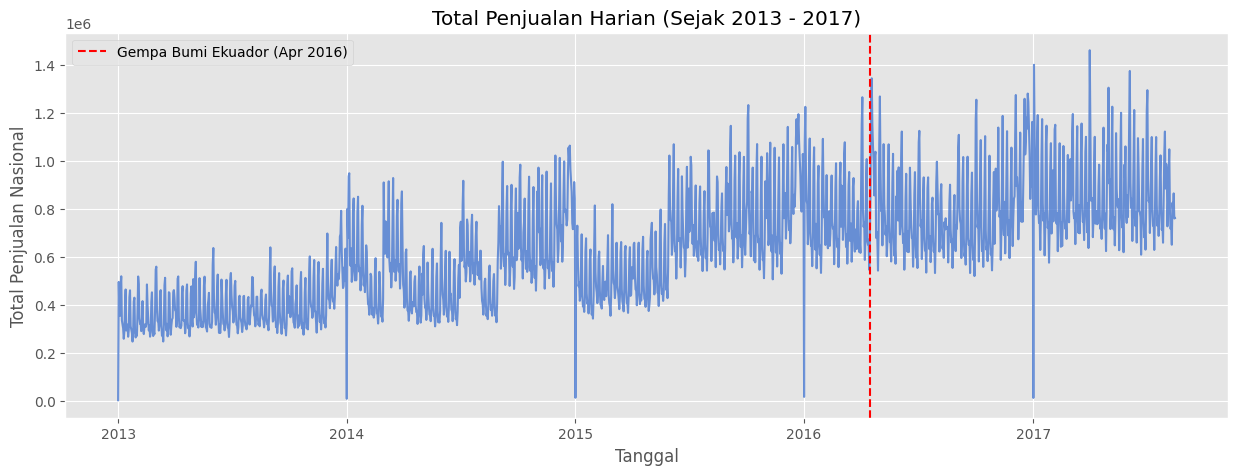

In [7]:
# Agregasi penjualan harian di seluruh toko
daily_sales = df_raw.groupby('date')['sales'].sum().reset_index()

plt.figure(figsize=(15, 5))
plt.plot(daily_sales['date'], daily_sales['sales'], alpha=0.8)
plt.title('Total Penjualan Harian (Sejak 2013 - 2017)')
plt.xlabel('Tanggal')
plt.ylabel('Total Penjualan Nasional')
plt.axvline(pd.to_datetime('2016-04-16'), color='red', linestyle='--', label='Gempa Bumi Ekuador (Apr 2016)')
plt.legend()
plt.savefig('outputs/2_tren_penjualan_nasional.png')
print("Grafik 2 (Tren Nasional) telah disave ke notebooks/outputs/2_tren_penjualan_nasional.png")
plt.show(block=False)
plt.pause(2)

Terlihat dua fenomena penting:
1. Spike Ekstrem setiap akhir tahun (Natal/Tahun Baru).
2. Pola tak terduga setelah peristiwa Gempa Bumi Ekuador pada **16 April 2016**, di mana ada donasi/pasokan massal berupa air minum dan makanan ke daerah terdampak.

### 3. Mendeteksi Outlier Maksimal yang Merusak RMSE

In [8]:
# Melihat daftar produk (Family) dengan rata-rata penjualan vs maksimal penjualan tertinggi
family_stats = df_raw.groupby('family')['sales'].agg(['mean', 'max', 'std']).sort_values(by='max', ascending=False)
display(family_stats.head(10)) if 'display' in globals() else print(family_stats.head(10))

# Mari kita isolasi nilai persentil ke-99 dan ke-99.9
p99 = np.percentile(df_raw['sales'], 99)
p99_9 = np.percentile(df_raw['sales'], 99.9)

print(f"Nilai Persentil 99  : {p99}")
print(f"Nilai Persentil 99.9: {p99_9}")

                         mean         max          std
family                                                
GROCERY I         3776.972100  124717.000  2874.208845
MEATS              341.849965   89576.360   455.908498
BEVERAGES         2385.793151   25413.000  2307.882305
PRODUCE           1349.352123   17850.615  2186.481332
FROZEN FOODS       154.766954   14541.550   324.971305
POULTRY            350.532292   12143.201   400.511631
CLEANING          1072.416744   11377.000   734.681493
PERSONAL CARE      270.432513    7504.000   226.512007
DAIRY              709.154889    5636.000   671.949638
LIQUOR,WINE,BEER    85.187824    4821.000   126.555637
Nilai Persentil 99  : 5507.0
Nilai Persentil 99.9: 12076.22554800072


**Kesimpulan EDA Data Preparation & Rencana Cleansing:**
1. **Clipping/Winsorization:** Nilai target (Q) yang melampaui persentil 99.9 (outlier irasional) harus dipangkas agar prediksi pohon tak terdistorsi oleh satu-dua hari ekstrem (seperti borongan supermarket).
2. **Zero-Sales Handling:** Baris yang nol terus-menerus sejak awal untuk family toko tertentu sebelum *first sale* (produk belum rilis) sebaiknya **dibuang** / didrop dari fase training agar model tidak mempelajari data mati.
3. **Gempa Bumi:** Bisa di-*create* semacam filter atau marker bobot.

Lanjut ke tahap *Cleansing* dengan memodifikasi `feature_engineering.py`!

### 4. Interactive Data Exploration (D-Tale)
Menggunakan sampel 5% dari data mentah (~150.000 baris) untuk disajikan ke dalam GUI interaktif bergaya canggih tanpa meledakkan memori RAM. Anda dapat membuat korelasi, mendeteksi missing values, dan melihat chart tanpa kode!

In [9]:
import dtale

# Ambil 5% sampel acak
sample_size = int(len(df_raw) * 0.05)
print(f"Me-render D-Tale GUI menggunakan {sample_size:,} baris acak...")

df_sample = df_raw.sample(n=sample_size, random_state=42)
d = dtale.show(df_sample)

# Membuka langsung ke default web browser Anda
d.open_browser()
print(f"Jendela D-Tale telah dibuka. Jika tidak otomatis terbuka, klik link ini: {d.main_url()}")

Me-render D-Tale GUI menggunakan 150,044 baris acak...
http://LAPTOP-Q61VATS8:40000/dtale/main/1
Jendela D-Tale telah dibuka. Jika tidak otomatis terbuka, klik link ini: None
